In [1]:
import numpy as np
import matplotlib.pyplot as plt

path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"

path1 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp1_alpha2_Loc5_True19_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp2_alpha2_Loc5_True19_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp3_alpha2_Loc5_True19_kindFULL_2D.npz'

data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)

xa1    = data1['xa'][:]
yo1    = data1['yo'][:]
atemp1 = data1['steps'][:]
ox1,oy1,oz1 = data1['ox'][:], data1['oy'][:], data1['oz'][:]
deps1 = data1['deps'][:]
print('deps1', deps1.shape)
print('Shape xa1', xa1.shape)
print(f'yo {yo1.shape}')
print(f'steps {atemp1}')

xa2    = data2['xa'][:]
yo2    = data2['yo'][:]
atemp2 = data2['steps'][:]
ox2,oy2,oz2 = data2['ox'][:], data2['oy'][:], data2['oz'][:]
deps2 = data2['deps'][:]
print('Shape xa2', xa2.shape)
print(f'yo {yo2.shape}')
print(f'steps {atemp2}')

xa3    = data3['xa'][:]
yo3    = data3['yo'][:]
atemp3 = data3['steps'][:]
ox3,oy3,oz3 = data3['ox'][:], data3['oy'][:], data3['oz'][:]
deps3 = data3['deps'][:]
print('Shape xa3', xa3.shape)
print(f'yo3 {yo3.shape}')
print(f'steps {atemp3}')

deps1 (1, 43)
Shape xa1 (77, 1, 43, 29, 8)
yo (43,)
steps [1.]
Shape xa2 (77, 1, 43, 29, 8)
yo (43,)
steps [0.04742587 0.95257413]
Shape xa3 (77, 1, 43, 29, 8)
yo3 (43,)
steps [0.00380626 0.20781451 0.78837925]


In [2]:
import sys, pathlib
REPO_ROOT = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/fortran"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from cletkf_wloc import common_da as cda

truth = data1['truth'][:]
xn,yn,zn = xa1.shape[0:3]
ref = np.zeros((xn,yn,zn))
for xi in np.arange(xn):
    for yi in np.arange(yn):
        for zi in np.arange(zn):
            qr = truth[xi, yi, zi, 1]
            qs = truth[xi, yi, zi, 2]
            qg = truth[xi, yi, zi, 0]
            tt = truth[xi, yi, zi, 3]
            pp = truth[xi, yi, zi, 4]

            ref[xi,yi,zi] = cda.calc_ref(qr, qs, qg, tt, pp)

In [3]:
def tight_bbox_from_field(field2d, threshold=0.0, pad=2):
    """
    Return (xmin, xmax, zmin, zmax) axis limits in index space for
    the region where field2d > threshold. pad is in grid cells.
    """
    a = np.asarray(field2d)
    mask = a > threshold
    if not np.any(mask):
        # fall back to full domain
        xn, zn = a.shape
        return -0.5, xn - 0.5, -0.5, zn - 0.5
    ix, iz = np.where(mask)           # ix ~ x-index (first dim), iz ~ z-index (second dim)
    xn, zn = a.shape
    xmin = max(ix.min() - pad, 0)
    xmax = min(ix.max() + pad, xn - 1)
    zmin = max(iz.min() - pad, 0)
    zmax = min(iz.max() + pad, zn - 1)
    # use half-cell edges for pretty bounds
    return xmin - 0.5, xmax + 0.5, zmin - 0.5, zmax + 0.5

def plot_observations(data):
    truth = data['truth'][:]
    xa    = data['xa'][:]
    hxf   = data['hxf'][:]
    xn,yn,zn = xa.shape[0:3]
    yo1    = data['yo'][:]
    atemp1 = data['steps'][:]
    ox1,oy1,oz1 = data['ox'][:], data['oy'][:], data['oz'][:]
    deps1 = data['deps'][:]
    ref = np.zeros((xn,yn,zn))
    for xi in np.arange(xn):
        for yi in np.arange(yn):
            for zi in np.arange(zn):
                qr = truth[xi, yi, zi, 1]
                qs = truth[xi, yi, zi, 2]
                qg = truth[xi, yi, zi, 0]
                tt = truth[xi, yi, zi, 3]
                pp = truth[xi, yi, zi, 4]

                ref[xi,yi,zi] = cda.calc_ref(qr, qs, qg, tt, pp)
    ref2d = ref[:,0,:]
    xmin, xmax, zmin, zmax = tight_bbox_from_field(ref2d, threshold=5.0, pad=2)

    fig, ax = plt.subplots(1, 3, figsize=(20, 4.5),dpi=300, facecolor='white')
    im=ax[0].scatter(ox1,oz1,c=yo1,cmap='Spectral_r', marker='o', s=35,vmin=5,vmax=40)

    fig.colorbar(im, ax=ax[0], label="Reflectivity (dBZ)")
    ax[0].set_title(f'Observations  $[y_0] (Nobs = {len(yo1)})$',fontsize=20)
    ax[0].set_aspect('equal','box')

    X, Z = np.meshgrid(np.arange(xn), np.arange(zn), indexing='ij')
    #im3 = ax[1].scatter(X.flatten(), Z.flatten(), c=ref[:,0,:].flatten(), cmap='Spectral_r', marker='o', s=10,vmin=0,vmax=50)
    #im2 = ax[1].pcolormesh(X, Z, hxf, cmap="Spectral_r", vmin=5, vmax=40, shading='auto')
    im2  = ax[1].scatter(ox1, oz1, c=np.nanmean(hxf[0,:,:],axis=1),cmap='Spectral_r', marker='o', s=35,vmin=5,vmax=40)
    #cd  = ax[1].scatter(ox1, oz1, s=12, color="white", alpha=0.6, edgecolor="none", rasterized=True)
    fig.colorbar(im2, ax=ax[1], label="Reflectivity (dBZ)")
    ax[1].set_title('Ensemble mean $ [\overline{ H[x_f] }]$',fontsize=20)
    ax[1].set_aspect('equal','box')

    im=ax[2].scatter(ox1,oz1,c=deps1,cmap='RdBu_r', marker='o', edgecolor="k", s=35,vmin=-20,vmax=20)

    fig.colorbar(im, ax=ax[2], label="Reflectivity (dBZ)")
    ax[2].set_title('Departure $[y_0 - \overline{ H[x_f] }]$',fontsize=20)
    ax[2].set_aspect('equal','box')

    xmin, xmax, zmin, zmax = tight_bbox_from_field(ref2d, threshold=5.0, pad=2)

    for a in ax:
        a.set_xlim(xmin, xmax)
        a.set_ylim(zmin, zmax)
        a.set_aspect('equal', 'box')
        cs = a.contour(ref2d.T,levels = [5,10], colors="k", linewidths=0.8)
        a.clabel(cs, fmt="%.0f", inline=True, fontsize=8)
    plt.tight_layout()
    plt.savefig('Observations_EnsembleMean_Departure.png', dpi=300)



    plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
def compute_conditional_rmse(analysis, truth, threshold=0.0, var_name="Variable"):
    """
    Compute RMSE only where variable exceeds threshold.
    
    Parameters
    ----------
    analysis : np.ndarray
        Analysis field
    truth : np.ndarray
        Truth field
    threshold : float
        Minimum value to include in RMSE calculation
    var_name : str
        Variable name for display
    
    Returns
    -------
    rmse : float
        Conditional RMSE
    n_points : int
        Number of points above threshold
    """
    # Mask where truth exceeds threshold
    mask = truth > threshold
    n_points = mask.sum()
    
    if n_points == 0:
        print(f"Warning: No points above threshold {threshold} for {var_name}")
        return np.nan, 0
    
    # Compute RMSE only on masked points
    rmse = np.sqrt(mean_squared_error(
        truth[mask].flatten(),
        analysis[mask].flatten()
    ))
    
    return rmse, n_points

def plot_error_analysis(data1, data2, data3):
    # Define file paths
    truth = data1['truth'][:]
    xa    = data1['xa'][:]
    xn,yn,zn = xa.shape[0:3]
    ref = np.zeros((xn,yn,zn))
    for xi in np.arange(xn):
        for yi in np.arange(yn):
            for zi in np.arange(zn):
                qr = truth[xi, yi, zi, 1]
                qs = truth[xi, yi, zi, 2]
                qg = truth[xi, yi, zi, 0]
                tt = truth[xi, yi, zi, 3]
                pp = truth[xi, yi, zi, 4]

                ref[xi,yi,zi] = cda.calc_ref(qr, qs, qg, tt, pp)
    ref2d = ref[:,0,:]
    file_paths = {
        'LETKF'   : data1,
        'LETKF-T2': data2,
        'LETKF-T3': data3
    }

    # Variable names
    variables = {
        0: r'Graupel $[g/kg]$',
        3: r'Temperature $[ ^{ \circ } C]$',
        7: r'Vertical Wind $[m/s]$'
    }

    fig, axs = plt.subplots(3, 3, figsize=(18, 12), facecolor='white')
    for i, (var_index, var_name) in enumerate(variables.items()):
        if var_index==0:
            factor=1000
        else:
            factor=1
        contour_levels = {}  # Store contour levels and ticks per row
        err_maxs = []
        for col_index, (col_name, data) in enumerate(file_paths.items()):
            xa = factor*data['xa'][:, 0, :, :, :]
            true_state = factor*data['truth'][:, 0, :, :]
            mean_xa = np.nanmean(xa, axis=2)
            analysis_field = mean_xa[:, :, var_index]
            true_field = true_state[:, :, var_index]
            idx_zero = true_field == 0
            true_field[idx_zero] = np.nan  # Set to NaN to avoid division by zero
            error_analysis = analysis_field - true_field        #print(f'Error analysis shape: {error_analysis}')
            err_maxs.append(np.nanmax(np.abs(error_analysis)))

        err_max = np.nanmax(err_maxs)
        contour_levels['error'] = np.linspace(-err_max, err_max, 20)

        for col_index, (col_name, data) in enumerate(file_paths.items()):

            xa = factor*data['xa'][:, 0, :, :, :]
            true_state = factor*data['truth'][:, 0, :, :]
            mean_xa = np.nanmean(xa, axis=2)
            analysis_field = mean_xa[:, :, var_index]
            true_field = true_state[:, :, var_index]
            # Avoid division by zero

            error_analysis = analysis_field - true_field
            # Analysis Error
            im = axs[i, col_index].contourf(error_analysis.T, cmap='RdBu_r', levels=contour_levels['error'])
            cb2 = fig.colorbar(im, ax=axs[i, col_index])
            if var_index==0:
                rmse = np.sqrt(mean_squared_error(true_field, analysis_field))
                rmse_cond, n_pts = compute_conditional_rmse(analysis_field, true_field, threshold=0.001,var_name="Graupel")
                axs[i, col_index].set_title(f"{col_name} \n  RMSE: {rmse:.3f} \n  RMSE[Truth>0.001]: {rmse_cond:.3f}",fontsize=20)
            else:
                rmse = np.sqrt(mean_squared_error(true_field, analysis_field))
                axs[i, col_index].set_title(f"{col_name} | RMSE: {rmse:.3f} ",fontsize=20)
            cs = axs[i, col_index].contour(ref2d.T,levels = [5,10], colors="k", linewidths=0.8)
            axs[i, col_index].clabel(cs, fmt="%.0f", inline=True, fontsize=12)
            # Grid every 2 units and add square
            for ax in axs[:, col_index]:
                ax.grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.6)
                #ax.set_xticks(np.arange(0, forecast_field.shape[0], 5))
                #ax.set_yticks(np.arange(0, forecast_field.shape[1], 5))
            if col_index == 0:
                axs[i, col_index].set_ylabel(f"{var_name}", fontsize=20)
        # General title
        #fig.suptitle(f"Variable: {var_name}", fontsize=16)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('Error_Analysis_Multiple_Obs.png', dpi=300,transparent=False)
    plt.show()

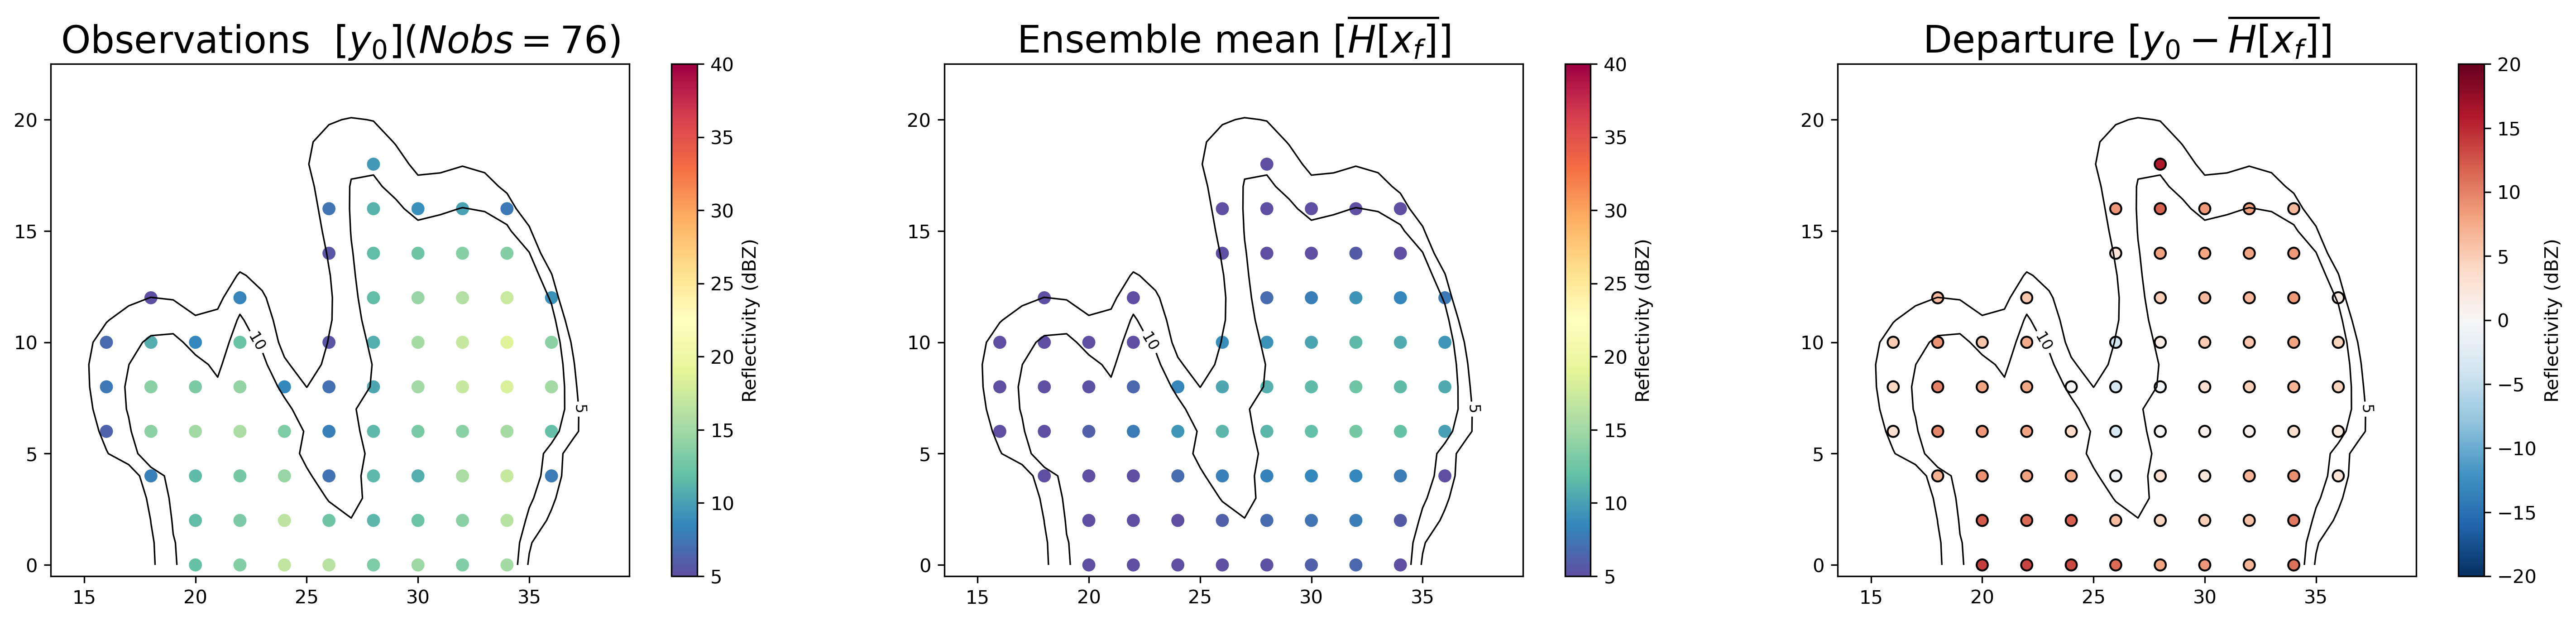

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import sys, pathlib
REPO_ROOT = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/fortran"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
from cletkf_wloc import common_da as cda
path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"
alpha=2
loc=5
true=20                
path1 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp1_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp2_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp3_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'

data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)
plot_observations(data1)


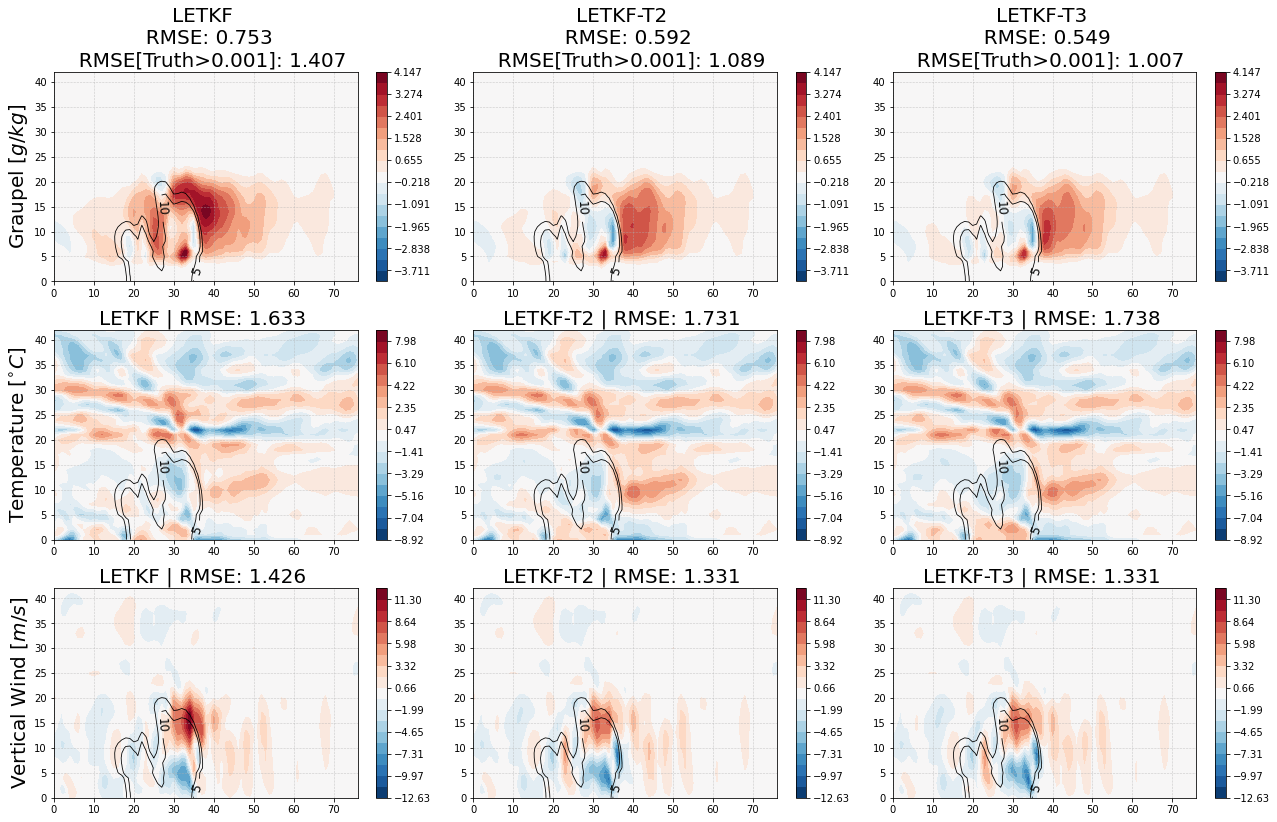

In [17]:
path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"
figpath_error = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/figures/error/"
figpath_obs = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/figures/observations/"
alpha_range = [0,1,2,3]
loc_range = [-1,1,2,3,4,5,6,7,8,9,10]
nens_range = np.arange(30)

alpha=2
loc=5
true=20                
path1 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp1_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp2_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp3_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)
plot_error_analysis(data1, data2, data3)

In [7]:
qg_truth = data1['truth'][:, 0, :, 0] 
print(f"Graupel range: [{qg_truth.min():.6f}, {qg_truth.max():.6f}] kg/kg")
print(f"Graupel mean:  {qg_truth.mean():.6f} kg/kg")
print(f"In g/kg: {qg_truth.mean()*1000:.3f} g/kg")

Graupel range: [0.000000, 0.006065] kg/kg
Graupel mean:  0.000200 kg/kg
In g/kg: 0.200 g/kg


In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def compute_conditional_rmse(analysis, truth, threshold=0.0, var_name="Variable"):
    """
    Compute RMSE only where variable exceeds threshold.
    
    Parameters
    ----------
    analysis : np.ndarray
        Analysis field
    truth : np.ndarray
        Truth field
    threshold : float
        Minimum value to include in RMSE calculation
    var_name : str
        Variable name for display
    
    Returns
    -------
    rmse : float
        Conditional RMSE
    n_points : int
        Number of points above threshold
    """
    # Mask where truth exceeds threshold
    mask = truth > threshold
    n_points = mask.sum()
    
    if n_points == 0:
        print(f"Warning: No points above threshold {threshold} for {var_name}")
        return np.nan, 0
    
    # Compute RMSE only on masked points
    rmse = np.sqrt(mean_squared_error(
        truth[mask].flatten(),
        analysis[mask].flatten()
    ))
    
    return rmse, n_points


def plot_error_analysis_with_improvement(data1, data2, data3):
    """
    Plot error analysis with absolute errors (col 1) and % improvement (cols 2-3).
    
    Parameters
    ----------
    data1 : dict
        LETKF (baseline) data
    data2 : dict
        LETKF-T2 data
    data3 : dict
        LETKF-T3 data
    """
    # Compute reference reflectivity
    truth = data1['truth'][:]
    xa = data1['xa'][:]
    xn, yn, zn = xa.shape[0:3]
    ref = np.zeros((xn, yn, zn))
    
    for xi in np.arange(xn):
        for yi in np.arange(yn):
            for zi in np.arange(zn):
                qr = truth[xi, yi, zi, 1]
                qs = truth[xi, yi, zi, 2]
                qg = truth[xi, yi, zi, 0]
                tt = truth[xi, yi, zi, 3]
                pp = truth[xi, yi, zi, 4]
                ref[xi, yi, zi] = cda.calc_ref(qr, qs, qg, tt, pp)
    
    ref2d = ref[:, 0, :]
    
    # Data dictionary
    file_paths = {
        'LETKF': data1,
        'LETKF-T2': data2,
        'LETKF-T3': data3
    }
    
    # Variable names
    variables = {
        0: r'Graupel $[g/kg]$',
        3: r'Temperature $[^{\circ}C]$',
        7: r'Vertical Wind $[m/s]$'
    }
    
    fig, axs = plt.subplots(3, 3, figsize=(20, 12), facecolor='white')
    
    for i, (var_index, var_name) in enumerate(variables.items()):
        # Scale factor for graupel
        if var_index == 0:
            factor = 1000
            threshold = 1.0  # 1 g/kg
        else:
            factor = 1
            threshold = None
        
        # Store errors for each method
        errors = {}
        rmse_values = {}
        
        # Compute errors for all methods
        for col_name, data in file_paths.items():
            xa = factor * data['xa'][:, 0, :, :, :]
            true_state = factor * data['truth'][:, 0, :, :]
            mean_xa = np.nanmean(xa, axis=2)
            
            analysis_field = mean_xa[:, :, var_index]
            true_field = true_state[:, :, var_index]
            
            # Compute error
            error = analysis_field - true_field
            errors[col_name] = error
            
            # Compute RMSE
            rmse = np.sqrt(mean_squared_error(true_field.flatten(), analysis_field.flatten()))
            rmse_values[col_name] = rmse
            
            # Compute conditional RMSE for graupel
            if var_index == 0:
                rmse_cond, n_pts = compute_conditional_rmse(
                    analysis_field, true_field, 
                    threshold=threshold, 
                    var_name="Graupel"
                )
                rmse_values[f"{col_name}_cond"] = rmse_cond
        
        # Determine color scale for absolute errors (column 1)
        err_max = np.nanmax(np.abs(errors['LETKF']))
        error_levels = np.linspace(-err_max, err_max, 20)
        
        # Column 1: Absolute error (LETKF baseline) - Spectral colormap
        im1 = axs[i, 0].contourf(errors['LETKF'].T, cmap='Spectral_r', levels=20)
        cb1 = fig.colorbar(im1, ax=axs[i, 0])
        
        # Title for column 1
        if var_index == 0:
            axs[i, 0].set_title(
                f"LETKF\nRMSE: {rmse_values['LETKF']:.3f}\n"
                f"RMSE[>1 g/kg]: {rmse_values['LETKF_cond']:.3f}",
                fontsize=18
            )
        else:
            axs[i, 0].set_title(f"LETKF\nRMSE: {rmse_values['LETKF']:.3f}", fontsize=18)
        
        # Add reflectivity contours
        cs = axs[i, 0].contour(ref2d.T, levels=[5, 10], colors="k", linewidths=0.8)
        axs[i, 0].clabel(cs, fmt="%.0f", inline=True, fontsize=10)
        axs[i, 0].grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.6)

        ox1,oy1,oz1 = data['ox'][:], data['oy'][:], data['oz'][:]
        axs[i, 0].scatter(ox1,oz1, c='DarkGrey',marker='o', s=15, alpha=0.5)

        # Columns 2-3: Percentage improvement
        for col_idx, method in enumerate(['LETKF-T2', 'LETKF-T3'], start=1):
            # Compute percentage improvement: 100 * (method - baseline) / baseline
            # Negative values = improvement (error decreased)
            baseline_error = np.abs(errors['LETKF'])
            method_error = np.abs(errors[method])
            
            # Define a minimum threshold for meaningful percentage calculation
            # Below this threshold, percentage changes are not meaningful
            min_threshold = 0.01 * err_max  # 1% of max error
            
            # Compute percentage improvement
            with np.errstate(divide='ignore', invalid='ignore'):
                pct_improvement = 100 * (method_error - baseline_error) / baseline_error
            
            # Mask out regions with very small baseline errors (not meaningful)
            # In these regions, absolute changes are tiny even if % is large
            if var_index==0:
                mask_small_errors = baseline_error < min_threshold
                pct_improvement = np.where(mask_small_errors, np.nan, pct_improvement)
            
            # Clip extreme values for better visualization
            pct_improvement = np.clip(pct_improvement, -100, 100)
            
            # Symmetric color scale around 0
            improvement_levels = np.arange(-100, 101, 10)


            #imp_max = max(50, np.nanmax(np.abs(pct_improvement)))  # At least ±50%
            #print(imp_max)
            # Plot percentage improvement (RdBu: blue=improvement, red=degradation)
            im = axs[i, col_idx].contourf(
                pct_improvement.T, 
                cmap='RdBu', 
                levels=improvement_levels,
                extend='both'
            )
            cb = fig.colorbar(im, ax=axs[i, col_idx])
            cb.set_label('% Change', fontsize=12)
            
            # Compute percentage RMSE improvement
            rmse_pct = 100 * (rmse_values[method] - rmse_values['LETKF']) / rmse_values['LETKF']
            
            # Title
            if var_index == 0:
                rmse_cond_pct = 100 * (rmse_values[f"{method}_cond"] - rmse_values['LETKF_cond']) / rmse_values['LETKF_cond']
                axs[i, col_idx].set_title(
                    f"{method}\nRMSE: {rmse_values[method]:.3f} ({rmse_pct:+.1f}%)\n"
                    f"RMSE[>1 g/kg]: {rmse_values[f'{method}_cond']:.3f} ({rmse_cond_pct:+.1f}%)",
                    fontsize=18
                )
            else:
                axs[i, col_idx].set_title(
                    f"{method}\nRMSE: {rmse_values[method]:.3f} ({rmse_pct:+.1f}%)",
                    fontsize=18
                )
            
            # Add reflectivity contours
            cs = axs[i, col_idx].contour(ref2d.T, levels=[5, 10], colors="k", linewidths=0.8)
            axs[i, col_idx].clabel(cs, fmt="%.0f", inline=True, fontsize=10)
            axs[i, col_idx].grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.6)
        
        # Y-label for first column
        axs[i, 0].set_ylabel(f"{var_name}", fontsize=20)
    
    # Add overall title
    #fig.suptitle(
    #    'Error Analysis: Absolute Errors (left) and % Improvement (center, right)\n'
    #    'Blue = Improvement, Red = Degradation',
    #    fontsize=22, y=0.995
    #)
    
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.savefig('Error_Analysis_with_Improvement.png', dpi=300, 
                transparent=False, facecolor='white', bbox_inches='tight')
    plt.show()

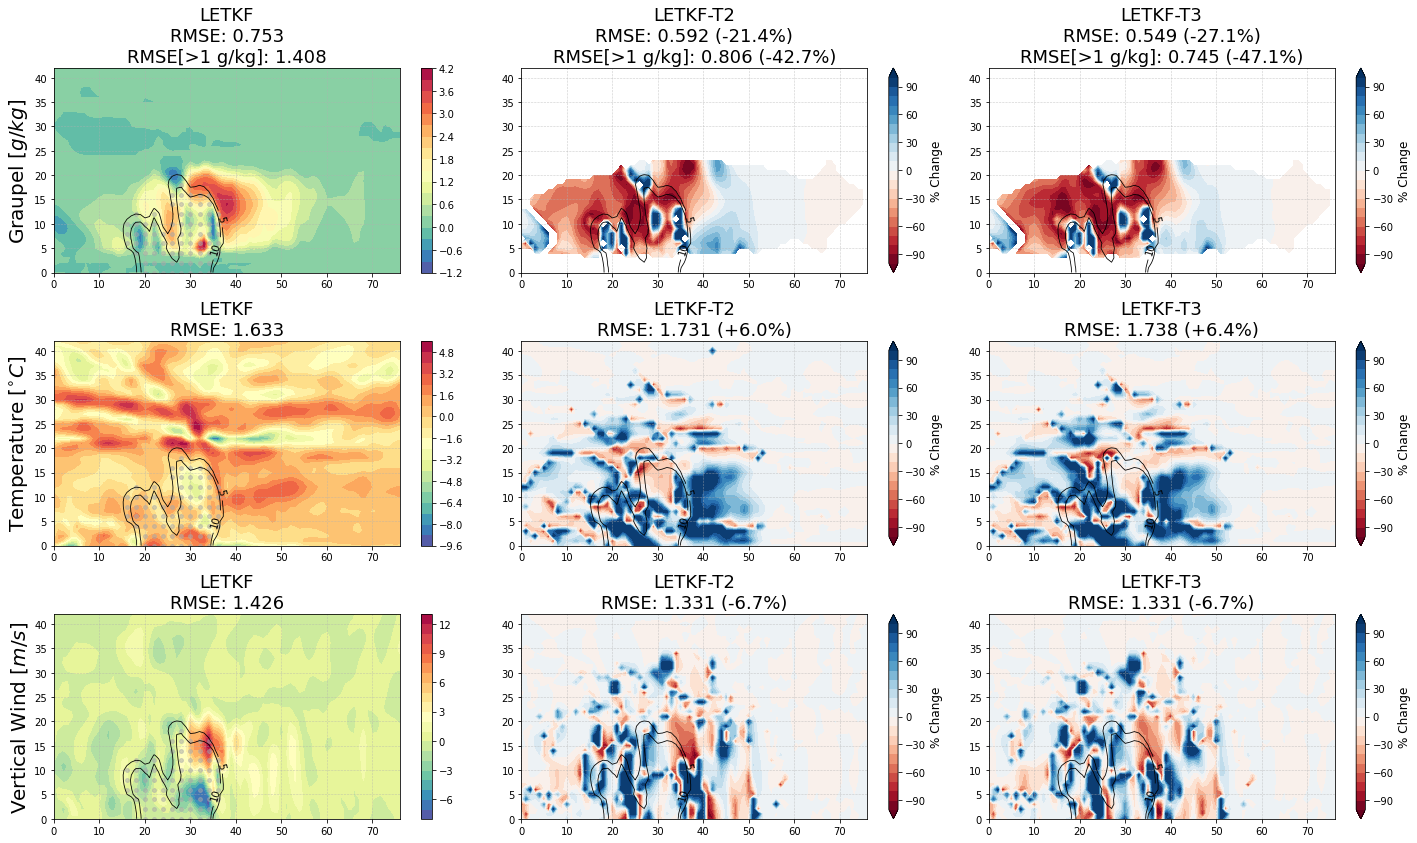

In [16]:
path = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/data/runs/full2d_multicycle/"
figpath_error = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/figures/error/"
figpath_obs = "/home/jorge.gacitua/datosmunin/wrf_python_Assimilation/figures/observations/"
alpha_range = [0,1,2,3]
loc_range = [-1,1,2,3,4,5,6,7,8,9,10]
nens_range = np.arange(30)

alpha=2
loc=5
true=20                
path1 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp1_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path2 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp2_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
path3 =  f'{path}Multicycle_v2_2023-12-16_19:00:00_temp3_alpha{alpha}_Loc{loc}_True{true}_kindFULL_2D.npz'
data1 = np.load(path1)
data2 = np.load(path2)
data3 = np.load(path3)
plot_error_analysis_with_improvement(data1, data2, data3)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

def compute_conditional_rmse(analysis, truth, threshold=0.0, var_name="Variable"):
    """
    Compute RMSE only where variable exceeds threshold.
    
    Parameters
    ----------
    analysis : np.ndarray
        Analysis field
    truth : np.ndarray
        Truth field
    threshold : float
        Minimum value to include in RMSE calculation
    var_name : str
        Variable name for display
    
    Returns
    -------
    rmse : float
        Conditional RMSE
    n_points : int
        Number of points above threshold
    """
    # Mask where truth exceeds threshold
    mask = truth > threshold
    n_points = mask.sum()
    
    if n_points == 0:
        print(f"Warning: No points above threshold {threshold} for {var_name}")
        return np.nan, 0
    
    # Compute RMSE only on masked points
    rmse = np.sqrt(mean_squared_error(
        truth[mask].flatten(),
        analysis[mask].flatten()
    ))
    
    return rmse, n_points


def plot_error_analysis_with_improvement(data1, data2, data3):
    """
    Plot error analysis with absolute errors (col 1) and % improvement (cols 2-3).
    
    Parameters
    ----------
    data1 : dict
        LETKF (baseline) data
    data2 : dict
        LETKF-T2 data
    data3 : dict
        LETKF-T3 data
    """
    # Compute reference reflectivity
    truth = data1['truth'][:]
    xa = data1['xa'][:]
    xn, yn, zn = xa.shape[0:3]
    ref = np.zeros((xn, yn, zn))
    
    for xi in np.arange(xn):
        for yi in np.arange(yn):
            for zi in np.arange(zn):
                qr = truth[xi, yi, zi, 1]
                qs = truth[xi, yi, zi, 2]
                qg = truth[xi, yi, zi, 0]
                tt = truth[xi, yi, zi, 3]
                pp = truth[xi, yi, zi, 4]
                ref[xi, yi, zi] = cda.calc_ref(qr, qs, qg, tt, pp)
    
    ref2d = ref[:, 0, :]
    
    # Data dictionary
    file_paths = {
        'LETKF': data1,
        'LETKF-T2': data2,
        'LETKF-T3': data3
    }
    
    # Variable names
    variables = {
        0: r'Graupel $[g/kg]$',
        3: r'Temperature $[^{\circ}C]$',
        7: r'Vertical Wind $[m/s]$'
    }
    
    fig, axs = plt.subplots(3, 3, figsize=(20, 12), facecolor='white')
    
    for i, (var_index, var_name) in enumerate(variables.items()):
        # Scale factor for graupel
        if var_index == 0:
            factor = 1000
            threshold = 1.0  # 1 g/kg
        else:
            factor = 1
            threshold = None
        
        # Store errors for each method
        errors = {}
        rmse_values = {}
        
        # Compute errors for all methods
        for col_name, data in file_paths.items():
            xa = factor * data['xa'][:, 0, :, :, :]
            true_state = factor * data['truth'][:, 0, :, :]
            mean_xa = np.nanmean(xa, axis=2)
            
            analysis_field = mean_xa[:, :, var_index]
            true_field = true_state[:, :, var_index]
            
            # Compute error
            error = analysis_field - true_field
            errors[col_name] = error
            
            # Compute RMSE
            rmse = np.sqrt(mean_squared_error(true_field.flatten(), analysis_field.flatten()))
            rmse_values[col_name] = rmse
            
            # Compute conditional RMSE for graupel
            if var_index == 0:
                rmse_cond, n_pts = compute_conditional_rmse(
                    analysis_field, true_field, 
                    threshold=threshold, 
                    var_name="Graupel"
                )
                rmse_values[f"{col_name}_cond"] = rmse_cond
        
        # Determine color scale for absolute errors (column 1)
        err_max = np.nanmax(np.abs(errors['LETKF']))
        error_levels = np.linspace(-err_max, err_max, 20)
        
        # Column 1: Absolute error (LETKF baseline) - Spectral colormap
        im1 = axs[i, 0].contourf(errors['LETKF'].T, cmap='Spectral_r', levels=error_levels)
        cb1 = fig.colorbar(im1, ax=axs[i, 0])
        
        # Title for column 1
        if var_index == 0:
            axs[i, 0].set_title(
                f"LETKF\nRMSE: {rmse_values['LETKF']:.3f}\n"
                f"RMSE[>1 g/kg]: {rmse_values['LETKF_cond']:.3f}",
                fontsize=18
            )
        else:
            axs[i, 0].set_title(f"LETKF\nRMSE: {rmse_values['LETKF']:.3f}", fontsize=18)
        
        # Add reflectivity contours
        cs = axs[i, 0].contour(ref2d.T, levels=[5, 10], colors="k", linewidths=0.8)
        axs[i, 0].clabel(cs, fmt="%.0f", inline=True, fontsize=10)
        axs[i, 0].grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.6)
        
        # Columns 2-3: Percentage improvement
        for col_idx, method in enumerate(['LETKF-T2', 'LETKF-T3']):
            # Compute percentage improvement: 100 * (method - baseline) / baseline
            # Negative values = improvement (error decreased)
            baseline_error = np.abs(errors['LETKF'])
            method_error = np.abs(errors[method])
            
            # Define a minimum threshold for meaningful percentage calculation
            # Below this threshold, percentage changes are not meaningful
            min_threshold = 0.01 * err_max  # 1% of max error
            
            # Compute percentage improvement
            with np.errstate(divide='ignore', invalid='ignore'):
                pct_improvement = 100 * (method_error - baseline_error) / baseline_error
            
            # Mask out regions with very small baseline errors (not meaningful)
            # In these regions, absolute changes are tiny even if % is large
            mask_small_errors = baseline_error < min_threshold
            pct_improvement = np.where(mask_small_errors, np.nan, pct_improvement)
            
            # Clip extreme values for better visualization
            pct_improvement = np.clip(pct_improvement, -100, 100)
            
            # Symmetric color scale around 0
            improvement_levels = np.arange(-100, 101, 10)
            
            # Plot percentage improvement (RdBu: blue=improvement, red=degradation)
            im = axs[i, col_idx].contourf(
                pct_improvement.T, 
                cmap='RdBu', 
                levels=improvement_levels,
                extend='both'
            )
            cb = fig.colorbar(im, ax=axs[i, col_idx+1])
            cb.set_label('% Change', fontsize=12)
            
            # Compute percentage RMSE improvement
            rmse_pct = 100 * (rmse_values[method] - rmse_values['LETKF']) / rmse_values['LETKF']
            
            # Title
            if var_index == 0:
                rmse_cond_pct = 100 * (rmse_values[f"{method}_cond"] - rmse_values['LETKF_cond']) / rmse_values['LETKF_cond']
                axs[i, col_idx+1].set_title(
                    f"{method}\nRMSE: {rmse_values[method]:.3f} ({rmse_pct:+.1f}%)\n"
                    f"RMSE[>1 g/kg]: {rmse_values[f'{method}_cond']:.3f} ({rmse_cond_pct:+.1f}%)",
                    fontsize=18
                )
            else:
                axs[i, col_idx+1].set_title(
                    f"{method}\nRMSE: {rmse_values[method]:.3f} ({rmse_pct:+.1f}%)",
                    fontsize=18
                )
            
            # Add reflectivity contours
            cs = axs[i, col_idx+1].contour(ref2d.T, levels=[5, 10], colors="k", linewidths=0.8)
            axs[i, col_idx+1].clabel(cs, fmt="%.0f", inline=True, fontsize=10)
            axs[i, col_idx+1].grid(True, which='major', linestyle='--', linewidth=0.6, alpha=0.6)
        
        # Y-label for first column
        axs[i, 0].set_ylabel(f"{var_name}", fontsize=20)
    
    # Add overall title
    fig.suptitle(
        'Error Analysis: Absolute Errors (left) and % Improvement (center, right)\n'
        'Blue = Improvement, Red = Degradation',
        fontsize=22, y=0.995
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.savefig('Error_Analysis_with_Improvement.png', dpi=300, 
                transparent=False, facecolor='white', bbox_inches='tight')
    plt.show()


# Example usage:
# plot_error_analysis_with_improvement(data_letkf, data_t2, data_t3)